# 보스턴 주택 가격 회귀 분석

보스턴 주택 데이터셋을 활용한 탐색적 데이터 분석 및 다중 회귀 모델 비교

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import pickle
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\14_Boston_Housing_ML\output'
DATA_PATH  = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\14_Boston_Housing_ML\resources\boston_housing.csv'

## 1. 데이터 로드 및 탐색

In [2]:
df = pd.read_csv(DATA_PATH)

# 컬럼 한글 설명
col_desc = {
    'crim':    '범죄율',
    'zn':      '주거지 비율',
    'indus':   '비소매업 비율',
    'chas':    '찰스강 더미',
    'nox':     '질소산화물 농도',
    'rm':      '평균 방 수',
    'age':     '노후 주택 비율',
    'dis':     '고용센터 거리',
    'rad':     '고속도로 접근성',
    'tax':     '재산세율',
    'ptratio': '학생-교사 비율',
    'b':       '흑인 비율 지수',
    'lstat':   '저소득층 비율',
    'medv':    '주택 중간가격($1000)',
}

print('Shape:', df.shape)
print('\n결측값:', df.isnull().sum().sum())
print('\n기초 통계:')
display(df.describe())
df.head()

Shape: (506, 14)

결측값: 0

기초 통계:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. EDA — 분포 및 상관관계

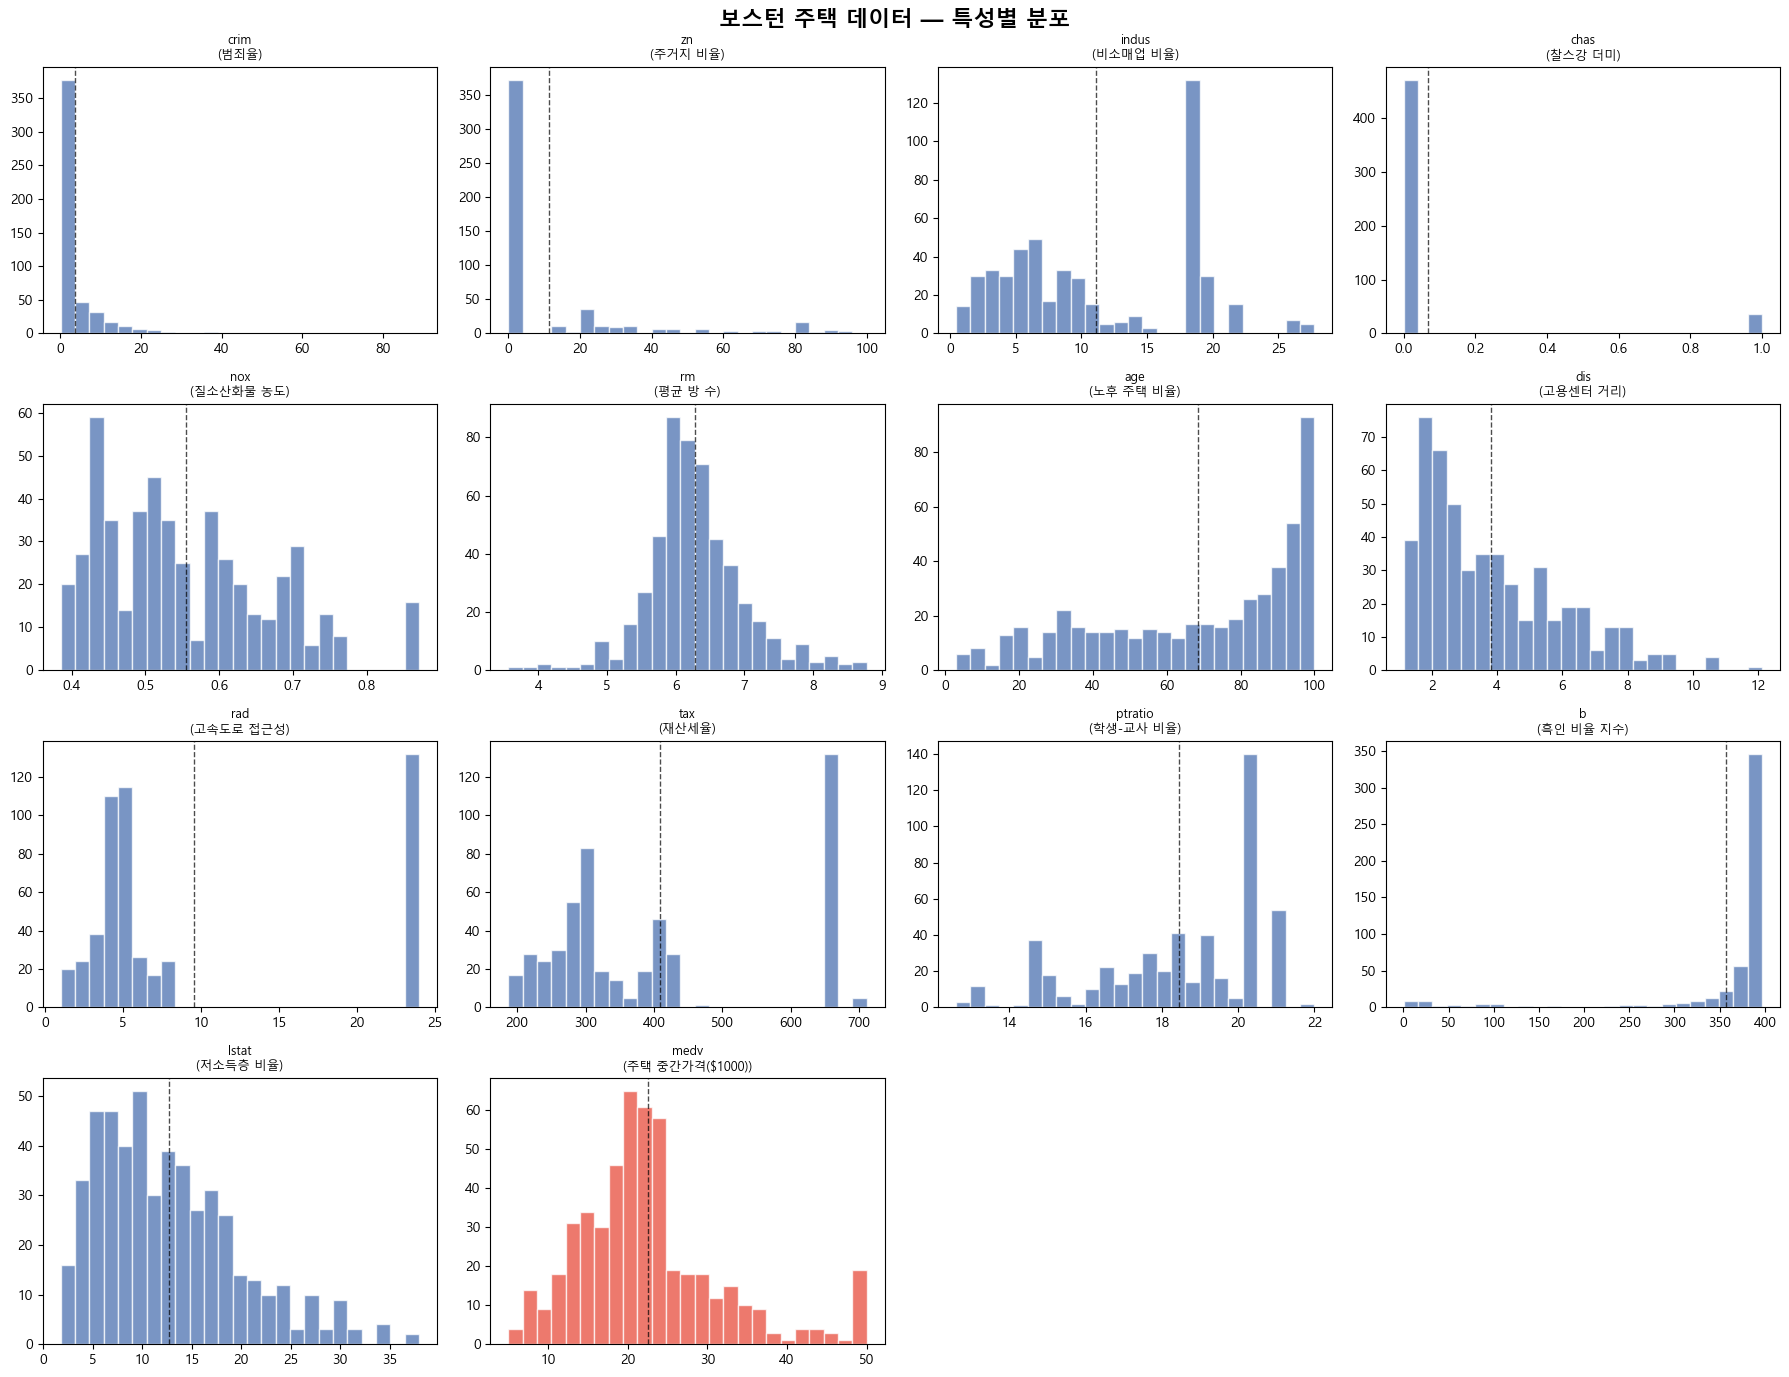

저장: 01_eda.png


In [3]:
features = [c for c in df.columns if c != 'medv']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('보스턴 주택 데이터 — 특성별 분포', fontsize=16, fontweight='bold')

all_cols = features + ['medv']
for i, (ax, col) in enumerate(zip(axes.flat, all_cols)):
    color = '#E74C3C' if col == 'medv' else '#4C72B0'
    ax.hist(df[col], bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(f'{col}\n({col_desc.get(col, "")})', fontsize=9)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, alpha=0.7)

# 마지막 빈 axes 숨기기
for ax in axes.flat[len(all_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_eda.png')

## 3. 특성 중요도 — 상관관계 및 타깃 관계

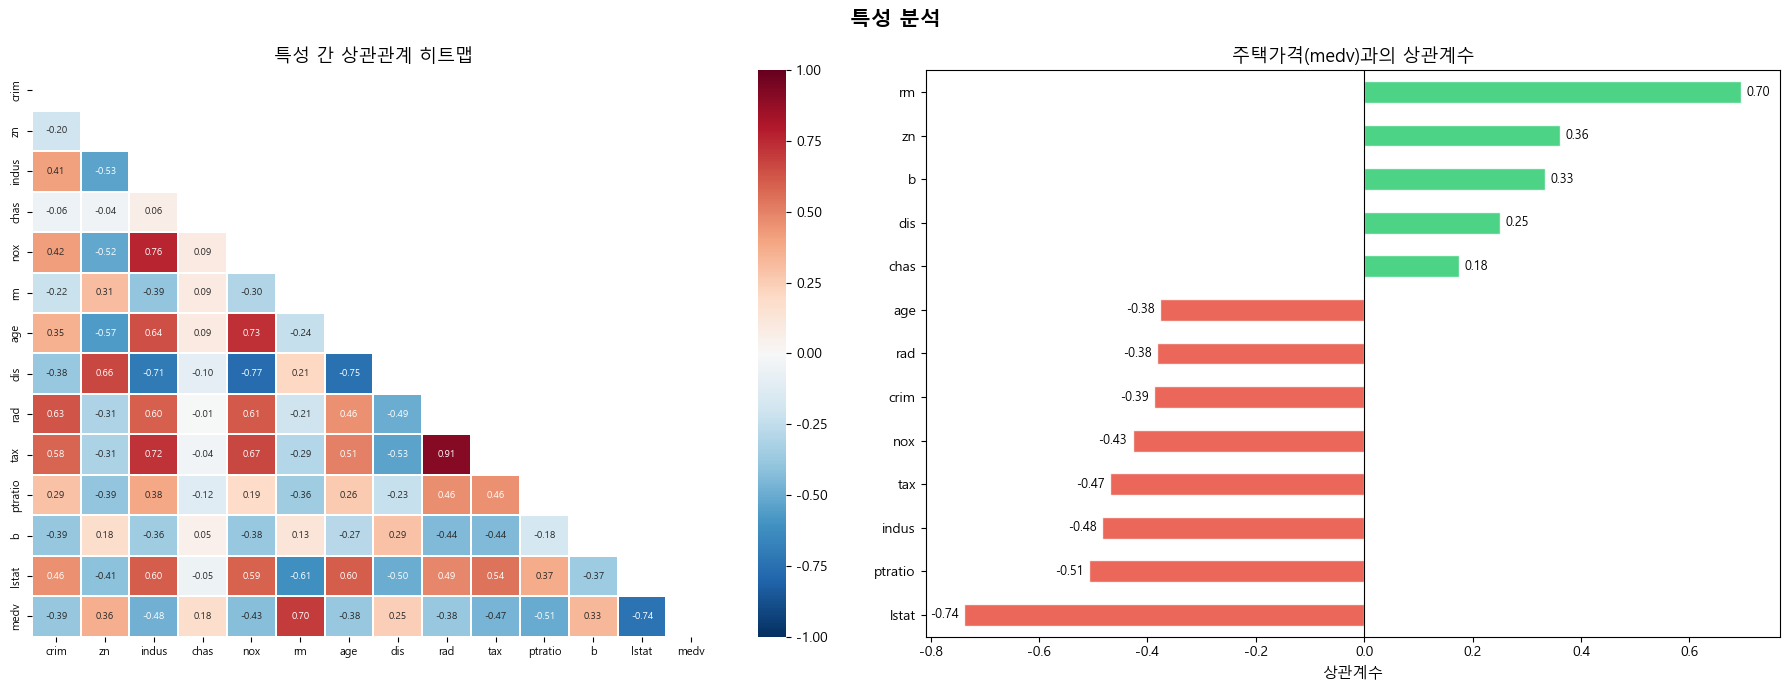

저장: 02_features.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('특성 분석', fontsize=15, fontweight='bold')

# 좌: 전체 상관관계 히트맵
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.3, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('특성 간 상관관계 히트맵', fontsize=13)
axes[0].tick_params(labelsize=8)

# 우: medv와의 상관관계 막대
corr_with_target = df.corr()['medv'].drop('medv').sort_values()
colors_bar = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=axes[1], color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].set_title('주택가격(medv)과의 상관계수', fontsize=13)
axes[1].set_xlabel('상관계수', fontsize=11)
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (v, name) in enumerate(zip(corr_with_target, corr_with_target.index)):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
                 f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_features.png')

## 4. 머신러닝 — 다중 회귀 모델 비교

In [5]:
X = df[features].values
y = df['medv'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'훈련: {X_train.shape}, 테스트: {X_test.shape}')

models = {
    'Linear Regression':   LinearRegression(),
    'Ridge':               Ridge(alpha=1.0),
    'Lasso':               Lasso(alpha=0.1),
    'ElasticNet':          ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree':       DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_rmse = np.sqrt(-cross_val_score(model, X_train_s, y_train,
                                       cv=kf, scoring='neg_mean_squared_error'))
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    results[name] = {'cv_rmse': cv_rmse.mean(), 'cv_std': cv_rmse.std(),
                     'test_rmse': rmse, 'mae': mae, 'r2': r2}
    print(f'{name:22s} | CV RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} | Test RMSE: {rmse:.3f} | R²: {r2:.4f}')

best_name = min(results, key=lambda k: results[k]['test_rmse'])
print(f'\n최고 모델: {best_name} (Test RMSE: {results[best_name]["test_rmse"]:.3f}, R²: {results[best_name]["r2"]:.4f})')

훈련: (404, 13), 테스트: (102, 13)


Linear Regression      | CV RMSE: 4.866 ± 0.799 | Test RMSE: 4.929 | R²: 0.6688
Ridge                  | CV RMSE: 4.863 ± 0.806 | Test RMSE: 4.931 | R²: 0.6685
Lasso                  | CV RMSE: 4.911 ± 0.900 | Test RMSE: 5.065 | R²: 0.6501
ElasticNet             | CV RMSE: 4.896 ± 0.900 | Test RMSE: 5.020 | R²: 0.6563
Decision Tree          | CV RMSE: 5.252 ± 1.044 | Test RMSE: 2.925 | R²: 0.8834


Random Forest          | CV RMSE: 3.738 ± 0.596 | Test RMSE: 2.813 | R²: 0.8921


Gradient Boosting      | CV RMSE: 3.561 ± 0.674 | Test RMSE: 2.492 | R²: 0.9153

최고 모델: Gradient Boosting (Test RMSE: 2.492, R²: 0.9153)


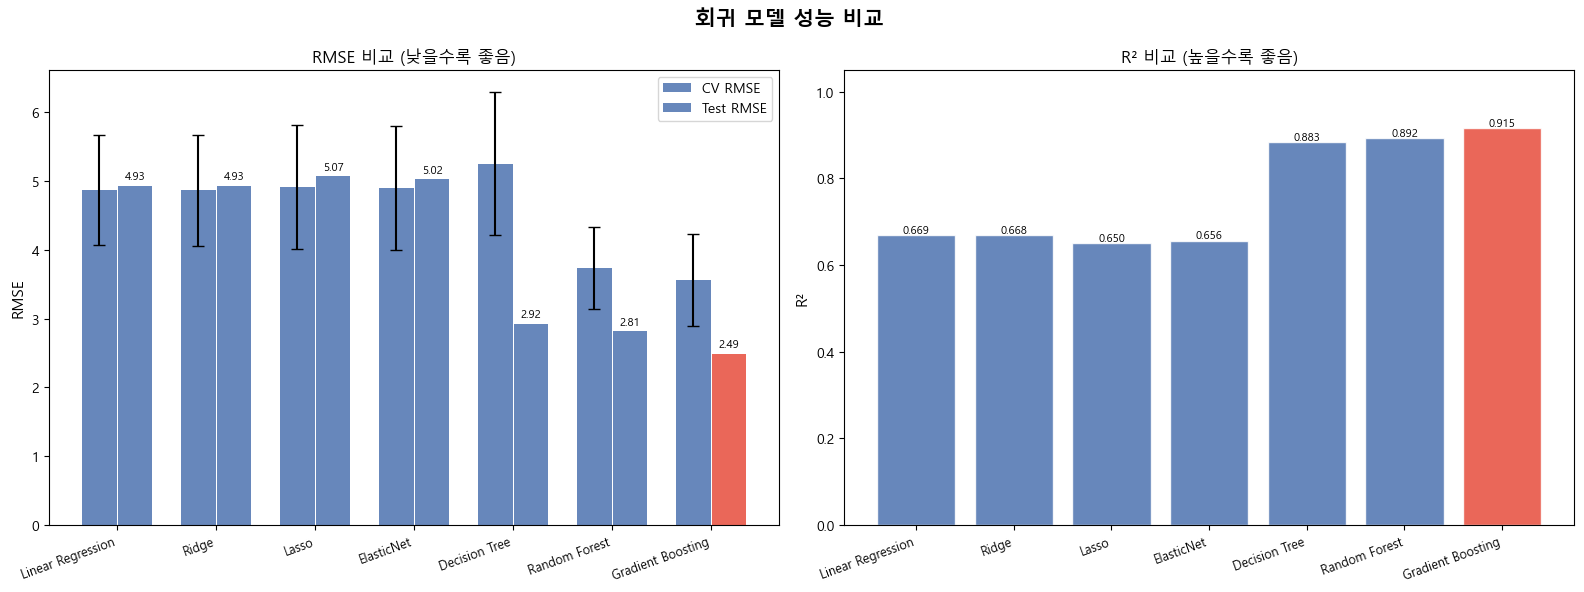

저장: 03_model_comparison.png


In [6]:
# 모델 비교 차트
names      = list(results.keys())
test_rmses = [results[n]['test_rmse'] for n in names]
r2_scores  = [results[n]['r2']        for n in names]
cv_rmses   = [results[n]['cv_rmse']   for n in names]
cv_stds    = [results[n]['cv_std']    for n in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('회귀 모델 성능 비교', fontsize=15, fontweight='bold')

x = np.arange(len(names))
colors_m = ['#E74C3C' if n == best_name else '#4C72B0' for n in names]

# RMSE 비교
bars1 = axes[0].bar(x - 0.18, cv_rmses, 0.35, label='CV RMSE', color='#4C72B0',
                    alpha=0.85, yerr=cv_stds, capsize=4)
bars2 = axes[0].bar(x + 0.18, test_rmses, 0.35, label='Test RMSE', color=colors_m, alpha=0.85)
axes[0].set_title('RMSE 비교 (낮을수록 좋음)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].legend(fontsize=10)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8)

# R² 비교
bars3 = axes[1].bar(x, r2_scores, color=colors_m, alpha=0.85, edgecolor='white')
axes[1].set_title('R² 비교 (높을수록 좋음)', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].set_ylim(0, 1.05)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_model_comparison.png')

## 5. 최고 모델 상세 분석

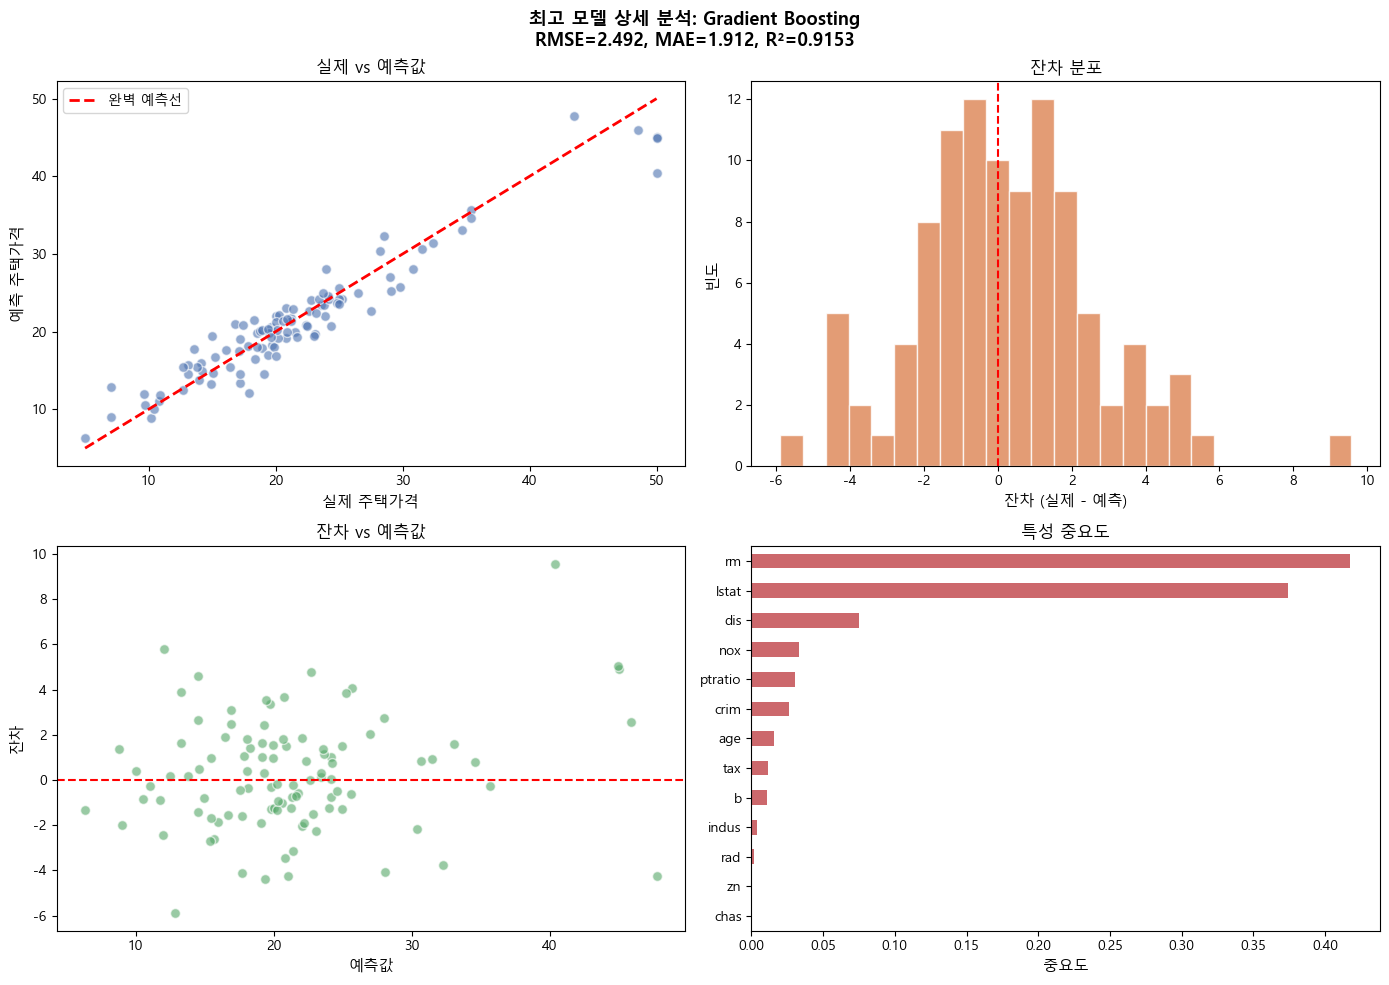

저장: 04_best_model_analysis.png


In [7]:
best_model = models[best_name]
y_pred     = best_model.predict(X_test_s)
residuals  = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'최고 모델 상세 분석: {best_name}\n'
             f'RMSE={results[best_name]["test_rmse"]:.3f}, '
             f'MAE={results[best_name]["mae"]:.3f}, '
             f'R²={results[best_name]["r2"]:.4f}',
             fontsize=13, fontweight='bold')

# 실제 vs 예측
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='#4C72B0', edgecolors='white', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0,0].plot(lims, lims, 'r--', linewidth=2, label='완벽 예측선')
axes[0,0].set_xlabel('실제 주택가격', fontsize=11)
axes[0,0].set_ylabel('예측 주택가격', fontsize=11)
axes[0,0].set_title('실제 vs 예측값', fontsize=12)
axes[0,0].legend(fontsize=10)

# 잔차 분포
axes[0,1].hist(residuals, bins=25, color='#DD8452', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_xlabel('잔차 (실제 - 예측)', fontsize=11)
axes[0,1].set_ylabel('빈도', fontsize=11)
axes[0,1].set_title('잔차 분포', fontsize=12)

# 잔차 vs 예측값
axes[1,0].scatter(y_pred, residuals, alpha=0.6, color='#55A868', edgecolors='white', s=50)
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_xlabel('예측값', fontsize=11)
axes[1,0].set_ylabel('잔차', fontsize=11)
axes[1,0].set_title('잔차 vs 예측값', fontsize=12)

# 특성 중요도 (Random Forest / GB 계열)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', ax=axes[1,1], color='#C44E52', alpha=0.85)
    axes[1,1].set_title('특성 중요도', fontsize=12)
    axes[1,1].set_xlabel('중요도', fontsize=11)
else:
    coefs = pd.Series(np.abs(best_model.coef_), index=features).sort_values()
    coefs.plot(kind='barh', ax=axes[1,1], color='#C44E52', alpha=0.85)
    axes[1,1].set_title('회귀 계수 절댓값', fontsize=12)
    axes[1,1].set_xlabel('|계수|', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_best_model_analysis.png')

## 6. 모델 저장

In [8]:
model_path = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\14_Boston_Housing_ML\workflows\boston_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler, 'features': features}, f)

print(f'모델 저장 완료: {model_path}')
print(f'최고 모델: {best_name}')
print(f'Test RMSE: {results[best_name]["test_rmse"]:.3f}')
print(f'Test MAE:  {results[best_name]["mae"]:.3f}')
print(f'Test R²:   {results[best_name]["r2"]:.4f}')

모델 저장 완료: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\14_Boston_Housing_ML\workflows\boston_model.pkl
최고 모델: Gradient Boosting
Test RMSE: 2.492
Test MAE:  1.912
Test R²:   0.9153
